# 10 Phase 3 — Hybrid Evaluation & Visualizations

---

## Purpose

Visual comparison of **Phase 3** artifacts: hybrid training dynamics, ablation study metrics, and optional bridge to **Phase 1 (ML)** / **Phase 2 (DL)** benchmarks. This notebook is **visualization-first** (minimal model loading).

### What you get
- Ablation tables and ranked bar charts (F1, AUC, accuracy, edge-case F1)
- Overall vs edge-case F1 grouped comparison
- Hybrid training curves (loss, validation F1, validation AUC)
- Optional **ML + DL + best hybrid** comparison bar chart
- Inline display of saved figures (`ablation_comparison`, `hybrid_training_curves`, and Phase 3 exports from this notebook)
- Exports refreshed plots under `figures/`

### Prerequisites
Run in order:
1. `06_hybrid_fusion.ipynb` → produces `metrics/hybrid_training_history.json`, `models/hybrid_model.pt`, etc.
2. `07_ablation_studies.ipynb` → produces `metrics/ablation_results.json`, `figures/ablation_comparison.png`

Earlier phases (optional for the bridge chart): `04_model_training.ipynb`, `08_dl_evaluation.ipynb` so `metrics/ml_vs_dl_comparison.json` exists.


## 1. Imports and paths

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path(".").resolve().parent
if not (PROJECT_ROOT / "metrics").exists():
    PROJECT_ROOT = Path(".").resolve()

METRICS_DIR = PROJECT_ROOT / "metrics"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = /Users/spylook/predictive-sales-analytics-engine


## 2. Load ablation results

In [2]:
ABLATION_PATH = METRICS_DIR / "ablation_results.json"
if not ABLATION_PATH.exists():
    raise FileNotFoundError(f"Run 07_ablation_studies.ipynb first. Missing: {ABLATION_PATH}")

with open(ABLATION_PATH, encoding="utf-8") as f:
    ablation_raw = json.load(f)

PRETTY = {
    "A_full_hybrid": "A — Full hybrid",
    "B_tabular_only": "B — Tabular only",
    "C_text_only": "C — Text only",
    "D_concat_no_gate": "D — Concat (no gate)",
    "E_frozen_text": "E — Frozen text encoder",
    "F_no_xgb_encode": "F — No XGB leaf encode",
}

rows = []
for key, m in ablation_raw.items():
    rows.append(
        {
            "variant_key": key,
            "variant": PRETTY.get(key, key),
            "f1": m.get("f1", np.nan),
            "auc": m.get("auc", np.nan),
            "acc": m.get("acc", np.nan),
            "edge_case_f1": m.get("edge_case_f1", np.nan),
        }
    )

ablation_df = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
display(Markdown("### Ablation metrics (sorted by F1)"))
display(ablation_df.style.format({"f1": "{:.4f}", "auc": "{:.4f}", "acc": "{:.4f}", "edge_case_f1": "{:.4f}"}))

### Ablation metrics (sorted by F1)

,variant_key,variant,f1,auc,acc,edge_case_f1
0,A_full_hybrid,A — Full hybrid,0.9761,0.9981,0.9767,0.8627
1,E_frozen_text,E — Frozen text encoder,0.9747,0.9986,0.9750,0.8624
2,B_tabular_only,B — Tabular only,0.9732,0.9975,0.9733,0.8596
3,D_concat_no_gate,D — Concat (no gate),0.9688,0.9987,0.9683,0.8480
4,F_no_xgb_encode,F — No XGB leaf encode,0.9593,0.9964,0.9600,0.7736
5,C_text_only,C — Text only,0.6203,0.6232,0.5817,0.3580


## 3. Ablation — horizontal bar charts (per metric)

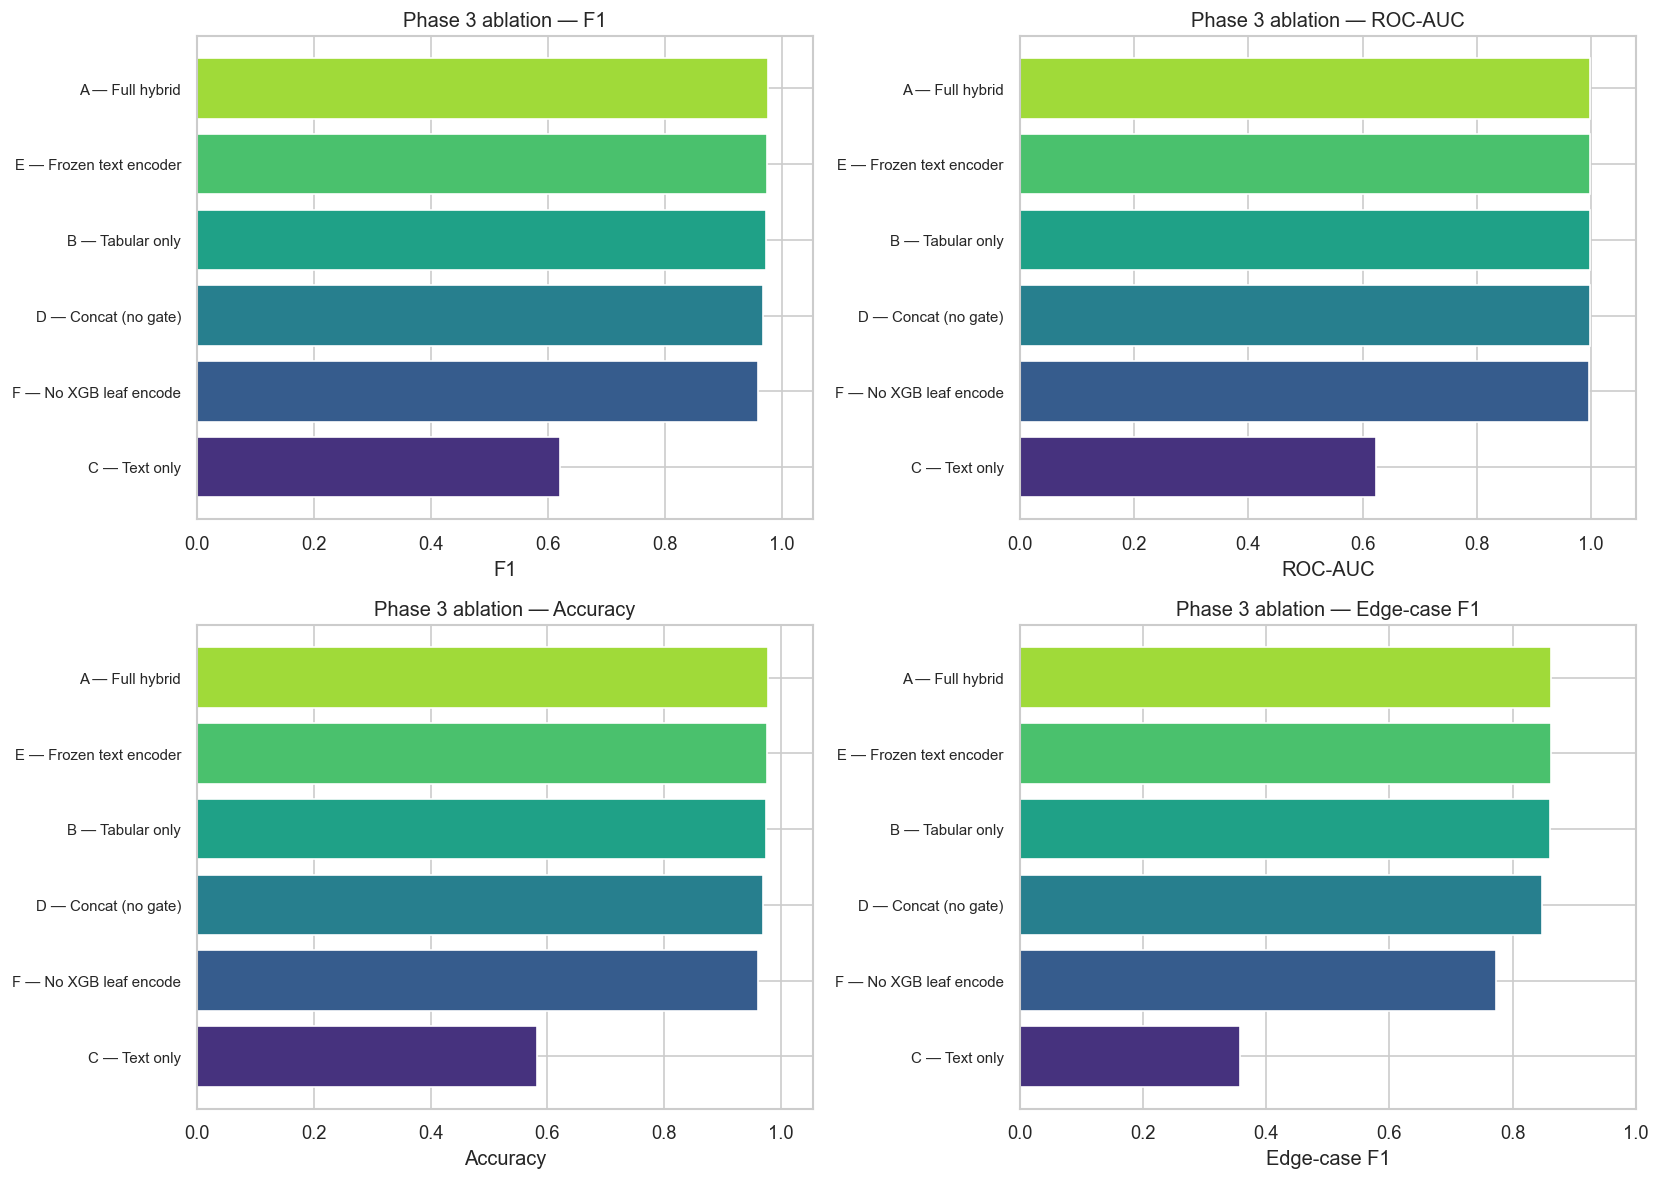

Saved /Users/spylook/predictive-sales-analytics-engine/figures/phase3_ablation_bars_4panel.png


In [3]:
plot_df = ablation_df.sort_values("f1", ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [("f1", "F1"), ("auc", "ROC-AUC"), ("acc", "Accuracy"), ("edge_case_f1", "Edge-case F1")]
colors = sns.color_palette("viridis", n_colors=len(plot_df))

for ax, (col, title) in zip(axes.ravel(), metrics):
    vals = plot_df[col].values
    y = np.arange(len(plot_df))
    ax.barh(y, vals, color=colors)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["variant"].values, fontsize=9)
    ax.set_xlabel(title)
    ax.set_title(f"Phase 3 ablation — {title}")
    ax.set_xlim(0, max(1.0, vals.max() * 1.08))

plt.tight_layout()
out = FIGURES_DIR / "phase3_ablation_bars_4panel.png"
plt.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved {out}")

## 4. Ablation — overall F1 vs edge-case F1 (grouped)

/var/folders/8m/p_ryzchj1rg0w3vm3p03f_k40000gn/T/ipykernel_60084/2290625460.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")


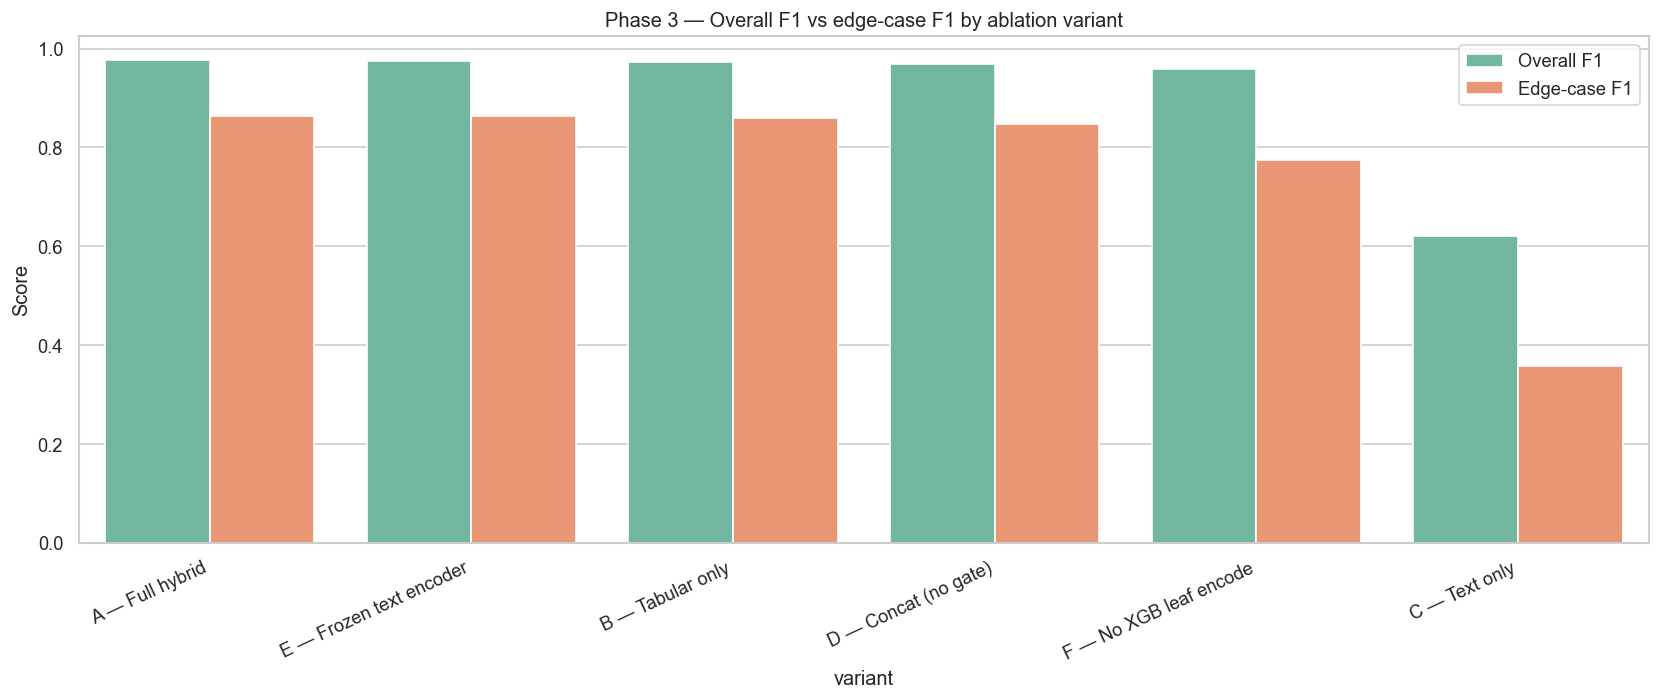

Saved /Users/spylook/predictive-sales-analytics-engine/figures/phase3_ablation_overall_vs_edge_f1.png


In [4]:
melted = ablation_df.melt(
    id_vars=["variant"],
    value_vars=["f1", "edge_case_f1"],
    var_name="metric",
    value_name="score",
)
melted["metric"] = melted["metric"].map({"f1": "Overall F1", "edge_case_f1": "Edge-case F1"})

order = ablation_df.sort_values("f1", ascending=False)["variant"].tolist()
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=melted, x="variant", y="score", hue="metric", order=order, ax=ax, palette="Set2")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.set_ylabel("Score")
ax.set_title("Phase 3 — Overall F1 vs edge-case F1 by ablation variant")
ax.legend(title="")
plt.tight_layout()
out = FIGURES_DIR / "phase3_ablation_overall_vs_edge_f1.png"
plt.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved {out}")

## 5. Ablation — heatmap (normalized rows for shape comparison)

Each row is min–max scaled so you can compare **relative** profile across variants (not absolute scale).

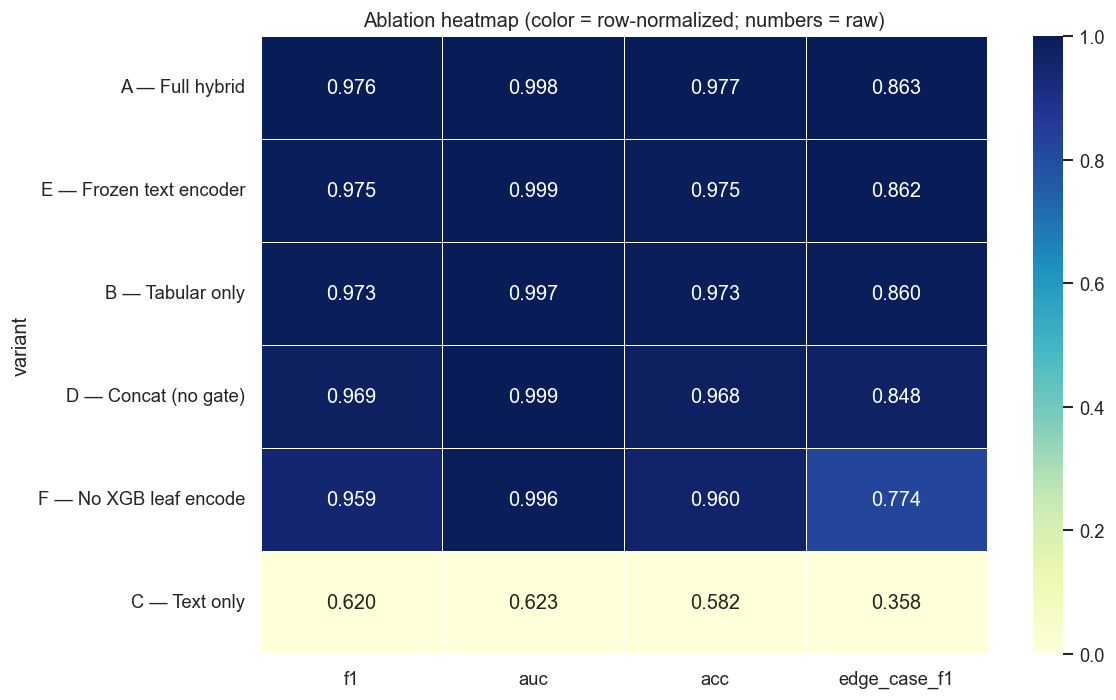

Saved /Users/spylook/predictive-sales-analytics-engine/figures/phase3_ablation_heatmap.png


In [5]:
hm = ablation_df.set_index("variant")[["f1", "auc", "acc", "edge_case_f1"]]
hm_norm = (hm - hm.min(axis=0)) / (hm.max(axis=0) - hm.min(axis=0) + 1e-12)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(hm_norm, annot=hm, fmt=".3f", cmap="YlGnBu", ax=ax, linewidths=0.5)
ax.set_title("Ablation heatmap (color = row-normalized; numbers = raw)")
plt.tight_layout()
out = FIGURES_DIR / "phase3_ablation_heatmap.png"
plt.savefig(out, bbox_inches="tight")
plt.show()
print(f"Saved {out}")

## 6. Hybrid training history (from `06_hybrid_fusion.ipynb`)

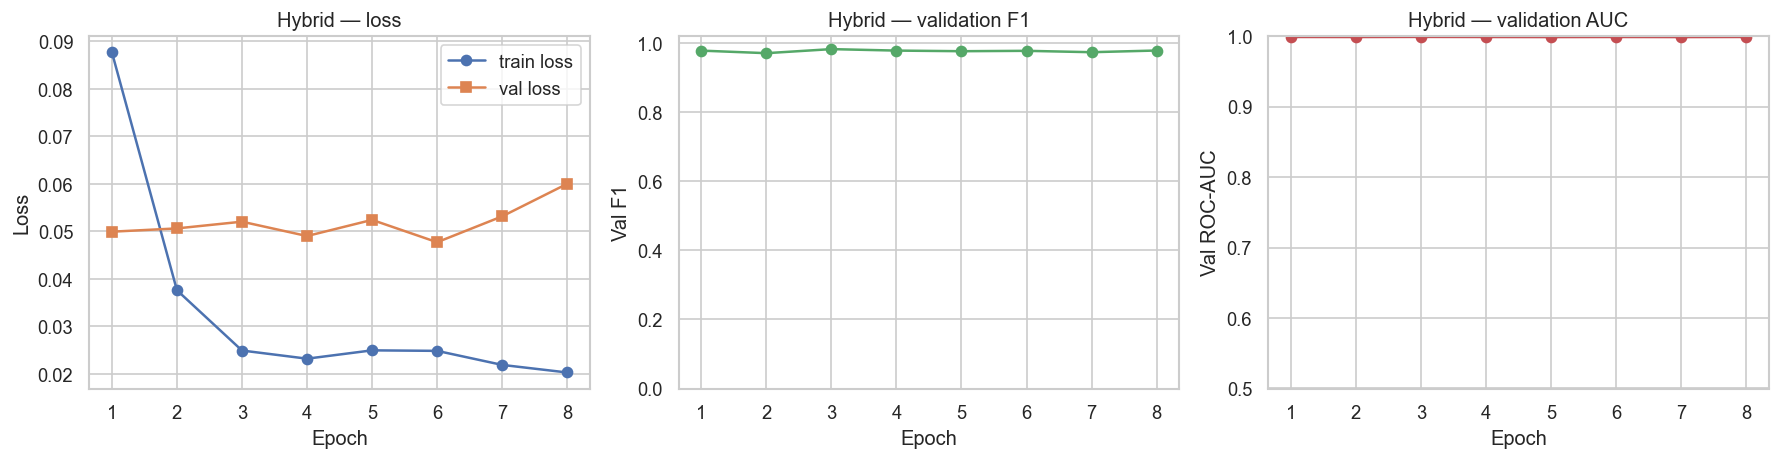

Saved /Users/spylook/predictive-sales-analytics-engine/figures/phase3_hybrid_training_curves.png


In [6]:
HIST_PATH = METRICS_DIR / "hybrid_training_history.json"
if not HIST_PATH.exists():
    print(f"Skip curves — missing {HIST_PATH}")
else:
    with open(HIST_PATH, encoding="utf-8") as f:
        hist = json.load(f)

    epochs = np.arange(1, len(hist["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, hist["train_loss"], marker="o", label="train loss")
    axes[0].plot(epochs, hist["val_loss"], marker="s", label="val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Hybrid — loss")
    axes[0].legend()

    axes[1].plot(epochs, hist["val_f1"], marker="o", color="C2")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Val F1")
    axes[1].set_title("Hybrid — validation F1")
    axes[1].set_ylim(0, 1.02)

    axes[2].plot(epochs, hist["val_auc"], marker="o", color="C3")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Val ROC-AUC")
    axes[2].set_title("Hybrid — validation AUC")
    axes[2].set_ylim(0.5, 1.0)

    plt.tight_layout()
    out = FIGURES_DIR / "phase3_hybrid_training_curves.png"
    plt.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")

## 7. Phase bridge — ML + DL + best hybrid (F1 & ROC-AUC)

Loads `metrics/ml_vs_dl_comparison.json` if present and appends **Full hybrid (Phase 3)** using the best ablation row (`A_full_hybrid` if available, else top F1).

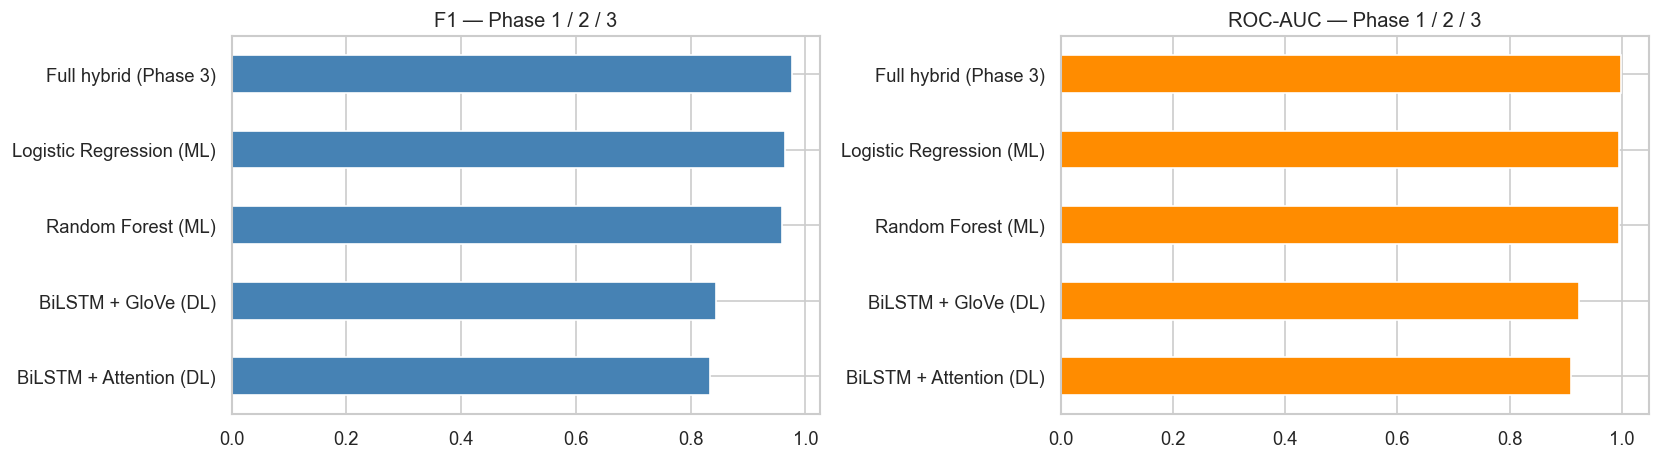

Saved /Users/spylook/predictive-sales-analytics-engine/figures/phase3_bridge_ml_dl_hybrid.png


In [7]:
bridge_path = METRICS_DIR / "ml_vs_dl_comparison.json"
best_row = ablation_df[ablation_df["variant_key"] == "A_full_hybrid"]
if best_row.empty:
    best_row = ablation_df.iloc[[0]]
f1_h = float(best_row["f1"].iloc[0])
auc_h = float(best_row["auc"].iloc[0])

if not bridge_path.exists():
    print(f"No bridge file: {bridge_path} — run Phase 2 evaluation notebook first.")
else:
    with open(bridge_path, encoding="utf-8") as f:
        bridge = json.load(f)

    f1_row = {"Full hybrid (Phase 3)": f1_h}
    auc_row = {"Full hybrid (Phase 3)": auc_h}
    for name, v in bridge.get("F1", {}).items():
        f1_row[name] = v
    for name, v in bridge.get("ROC-AUC", {}).items():
        auc_row[name] = v

    f1_df = pd.DataFrame([f1_row]).T.rename(columns={0: "F1"}).sort_values("F1", ascending=True)
    auc_df = pd.DataFrame([auc_row]).T.rename(columns={0: "ROC-AUC"}).sort_values("ROC-AUC", ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(f1_df) * 0.35)))
    f1_df.plot(kind="barh", ax=axes[0], legend=False, color="steelblue")
    axes[0].set_title("F1 — Phase 1 / 2 / 3")
    auc_df.plot(kind="barh", ax=axes[1], legend=False, color="darkorange")
    axes[1].set_title("ROC-AUC — Phase 1 / 2 / 3")
    plt.tight_layout()
    out = FIGURES_DIR / "phase3_bridge_ml_dl_hybrid.png"
    plt.savefig(out, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")

## 8. Saved figures from earlier notebooks (inline)

These are produced by `07_ablation_studies.ipynb`, `06_hybrid_fusion.ipynb`, and earlier cells in this notebook; shown here for a single Phase 3 dashboard view.

In [ ]:
candidates = [
    "ablation_comparison.png",
    "hybrid_training_curves.png",
    "phase3_hybrid_training_curves.png",
    "phase3_ablation_bars_4panel.png",
]
for name in candidates:
    p = FIGURES_DIR / name
    if p.exists():
        display(Markdown(f"### `{name}`"))
        display(Image(filename=str(p), width=900))
    else:
        print(f"(missing) {p}")

## 9. Summary (auto)

Use this cell output in reports or slides.

In [9]:
top = ablation_df.iloc[0]
summary = (
    f"**Best ablation (by F1):** {top['variant']} — "
    f"F1={top['f1']:.4f}, AUC={top['auc']:.4f}, Acc={top['acc']:.4f}, edge-case F1={top['edge_case_f1']:.4f}."
)
display(Markdown(summary))

**Best ablation (by F1):** A — Full hybrid — F1=0.9761, AUC=0.9981, Acc=0.9767, edge-case F1=0.8627.